# So sánh EfficientNetV2-S vs RegNetY-3.2GF cho nhận diện bệnh hại lá cà phê

Notebook này huấn luyện và đánh giá 2 kiến trúc (EfficientNetV2-S và RegNetY-3.2GF) trên bộ dữ liệu `D:/MSE_AI/MLE/dataset` (4 lớp: Healthy, Miner, Phoma, Rust), theo đúng quy trình mô tả trong `.claude/readme.md`.

> **Lưu ý:** đề tài gốc chọn RegNetY-4GF, nhưng `torchvision` không cung cấp sẵn biến thể 4.0GF (chỉ có 3.2GF và 8.0GF). Notebook dùng **RegNetY-3.2GF** — biến thể có sẵn gần nhất về FLOPs — để có trọng số pretrained ImageNet chính thức từ torchvision.

## Cách chạy
1. Trong VS Code, góc trên bên phải notebook, bấm **Select Kernel** → chọn **`Python (agriviet-ai / CoffeeLeaf-AI)`** (môi trường conda `agriviet-ai`, đã cài PyTorch bản CUDA phù hợp với RTX 5060).
2. Chạy lần lượt từng cell từ trên xuống (Run All hoặc `Shift+Enter` từng cell).
3. Cell **Kiểm tra môi trường** phải in ra `CUDA: True` và tên GPU — nếu `False`, xem mục Troubleshooting bên dưới trước khi train (train bằng CPU sẽ rất chậm).
4. Notebook train tuần tự 2 model x 15 epoch. Với ảnh 300px/224px, batch 32 trên RTX 5060 8GB, mỗi model mất khoảng 10-25 phút tuỳ IO đĩa — tổng thời gian ước tính 30-60 phút.
5. Kết quả cuối: bảng so sánh, biểu đồ Loss/Accuracy, Confusion Matrix, và các file được lưu ra thư mục hiện tại:
   - `best_efficientnetv2-s_model.pth`, `best_regnety-3.2gf_model.pth` (trọng số tốt nhất)
   - `model_comparison_summary.csv` (bảng số liệu tổng hợp)
   - `classification_report_*.txt` (báo cáo theo từng lớp bệnh)

## Troubleshooting
- **`CUDA: False`**: kernel đang dùng đúng `agriviet-ai` không? Kiểm tra lại bằng cell đầu tiên.
- **DataLoader treo/lỗi trên Windows**: hạ `NUM_WORKERS` xuống `0` trong cell Config rồi chạy lại.
- **Lỗi hết VRAM (CUDA out of memory)**: hạ `BATCH_SIZE` xuống 16 hoặc 8 trong cell Config.
- Notebook có thể chạy lại từ đầu an toàn (deterministic nhờ `SEED=42`); các file trọng số cũ sẽ bị ghi đè.

## 0. Kiểm tra môi trường

In [2]:
import torch
print("Torch version:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060


## 1. Import thư viện

In [3]:
import os
import random
import time
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchvision.models import regnet_y_3_2gf, RegNet_Y_3_2GF_Weights  # torchvision khong co san bien the 4.0GF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

print("Import OK")

Import OK


c:\Users\Admin\miniconda3\envs\agriviet-ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Cấu hình tổng quát

In [4]:
DATASET_DIR = r"D:\MSE_AI\MLE\dataset"
TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True  # Đảm bảo cuDNN convolution deterministic giữa các lần chạy
torch.backends.cudnn.benchmark = False     # Tắt auto-tuner (vốn có thể chọn thuật toán khác nhau mỗi lần chạy)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
NUM_EPOCHS = 15
NUM_WORKERS = 0               # Windows + multiprocessing DataLoader (num_workers>0) rất hay bị treo (deadlock)
                              # trong notebook (đặc biệt khi có phần mềm diệt virus can thiệp subprocess).
                              # 0 = load dữ liệu trong tiến trình chính, chậm hơn một chút nhưng ổn định.
                              # Nếu máy bạn chạy ổn định, có thể thử tăng lên 2 để tải ảnh nhanh hơn.
VAL_RATIO_FROM_TRAIN = 0.15  # tách 15% của thư mục Train làm Validation

print("=" * 65)
print(f"Thiết bị tính toán : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU                : {torch.cuda.get_device_name(0)}")
    print(f"VRAM khả dụng      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 65)

Thiết bị tính toán : cuda
GPU                : NVIDIA GeForce RTX 5060
VRAM khả dụng      : 8.55 GB


## 3. Kiểm tra dataset

Bộ dữ liệu đã được tách sẵn thành `Train/` (~80% mỗi lớp) và `test/` (~20% mỗi lớp, giữ nguyên làm tập kiểm thử độc lập). Notebook sẽ tách tiếp `Train/` thành train/val theo `VAL_RATIO_FROM_TRAIN` bằng Stratified Sampling.

In [5]:
def count_images(root_dir):
    counts = {}
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)
print("Train:", train_counts)
print("Test :", test_counts)

NUM_CLASSES = len(train_counts)
print(f"\nSố lớp bệnh: {NUM_CLASSES}")

Train: {'Healthy': 400, 'Miner': 400, 'Phoma': 400, 'Rust': 400}
Test : {'Healthy': 100, 'Miner': 100, 'Phoma': 100, 'Rust': 100}

Số lớp bệnh: 4


## 4. Pipeline dữ liệu (Data Augmentation + Stratified Split)

In [7]:
class TransformSubset(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x, y = self.base_dataset[self.indices[i]]
        return self.transform(x), y


def create_dataloaders(train_dir, test_dir, img_size, batch_size=32, val_ratio=0.15, num_workers=2):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    full_train_dataset = datasets.ImageFolder(train_dir)
    class_names = full_train_dataset.classes
    targets = full_train_dataset.targets

    train_idx, val_idx = train_test_split(
        np.arange(len(targets)), test_size=val_ratio, stratify=targets, random_state=SEED
    )

    train_ds = TransformSubset(full_train_dataset, train_idx, train_transform)
    val_ds = TransformSubset(full_train_dataset, val_idx, eval_transform)
    test_ds = datasets.ImageFolder(test_dir, transform=eval_transform)

    assert test_ds.classes == class_names, "Thứ tự nhãn lớp giữa Train và test không khớp!"

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True,
                               persistent_workers=num_workers > 0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=True,
                             persistent_workers=num_workers > 0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True,
                              persistent_workers=num_workers > 0)

    return train_loader, val_loader, test_loader, class_names

## 5. Xây dựng mô hình (Transfer Learning)

In [8]:
def build_model(model_type, num_classes):
    if model_type == 'EfficientNetV2-S':
        weights = EfficientNet_V2_S_Weights.DEFAULT
        model = efficientnet_v2_s(weights=weights)
        for param in model.features.parameters():
            param.requires_grad = False
        for param in model.features[5:].parameters():
            param.requires_grad = True
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(p=0.4, inplace=True), nn.Linear(in_features, num_classes))
        img_size = 300

    elif model_type == 'RegNetY-3.2GF':
        weights = RegNet_Y_3_2GF_Weights.DEFAULT
        model = regnet_y_3_2gf(weights=weights)
        for param in model.trunk_output.parameters():
            param.requires_grad = False
        for param in model.trunk_output[3].parameters():
            param.requires_grad = True
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(p=0.3), nn.Linear(in_features, num_classes))
        img_size = 224

    else:
        raise ValueError(f"Model không hỗ trợ: {model_type}")

    return model, img_size

## 6. Pipeline huấn luyện & kiểm thử độc lập

In [9]:
class DeepLearningPipeline:
    def __init__(self, model_name, model, img_size):
        self.model_name = model_name
        self.model = model.to(DEVICE)
        self.img_size = img_size
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.best_model_path = f"best_{model_name.lower().replace('-', '_')}_model.pth"

    def train_pipeline(self, train_loader, val_loader, epochs=15):
        print(f"\n>>> [1/2] BẮT ĐẦU HUẤN LUYỆN: {self.model_name.upper()}")
        print(f"    Số epoch: {epochs} | Batch/epoch (train): {len(train_loader)} | Batch/epoch (val): {len(val_loader)}")

        backbone_params = [p for n, p in self.model.named_parameters()
                            if 'classifier' not in n and 'fc' not in n and p.requires_grad]
        head_params = [p for n, p in self.model.named_parameters()
                        if ('classifier' in n or 'fc' in n) and p.requires_grad]

        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': 1e-5},
            {'params': head_params, 'lr': 1e-3},
        ], weight_decay=1e-2)

        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
        scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

        # In log rõ ràng (xuống dòng, không ghi đè) ~5 lần mỗi epoch, cộng thêm dòng
        # xác nhận NGAY khi batch đầu tiên xong — để biết chắc vòng lặp đã thực sự bắt đầu chạy,
        # không phải phụ thuộc vào việc notebook frontend có refresh đúng thanh tqdm hay không.
        train_log_every = max(1, len(train_loader) // 5)
        val_log_every = max(1, len(val_loader) // 3)

        best_val_acc = 0.0
        start_time = time.time()

        for epoch in range(epochs):
            # ----- Bước Training của epoch -----
            self.model.train()
            t_loss, t_corr, total_train = 0.0, 0, 0
            epoch_start = time.time()

            train_bar = tqdm(train_loader, desc=f"[{self.model_name}] Epoch {epoch+1:02d}/{epochs:02d} - Training",
                              unit="batch", leave=False)
            for batch_idx, (inputs, labels) in enumerate(train_bar):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    outputs = self.model(inputs)
                    loss = criterion(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                t_loss += loss.item() * inputs.size(0)
                t_corr += torch.sum(outputs.argmax(1) == labels)
                total_train += inputs.size(0)

                cur_acc = (t_corr.double() / total_train).item() * 100
                train_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{cur_acc:.2f}%")

                if batch_idx == 0 or (batch_idx + 1) % train_log_every == 0 or (batch_idx + 1) == len(train_loader):
                    pct = (batch_idx + 1) / len(train_loader) * 100
                    vram_now = f"{torch.cuda.memory_allocated() / (1024*1024):.0f} MB" if torch.cuda.is_available() else "N/A"
                    print(f"    [Train] Epoch {epoch+1:02d}/{epochs:02d} - Batch {batch_idx+1:03d}/{len(train_loader):03d} "
                          f"({pct:5.1f}%) | loss={t_loss/total_train:.4f} acc={cur_acc:.2f}% "
                          f"| đã xử lý {total_train} ảnh | {time.time()-epoch_start:.1f}s | VRAM={vram_now}",
                          flush=True)

            scheduler.step()

            # ----- Bước Validation của epoch -----
            self.model.eval()
            v_loss, v_corr, total_val = 0.0, 0, 0

            val_bar = tqdm(val_loader, desc=f"[{self.model_name}] Epoch {epoch+1:02d}/{epochs:02d} - Validation",
                            unit="batch", leave=False)
            with torch.no_grad():
                for batch_idx, (inputs, labels) in enumerate(val_bar):
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                        outputs = self.model(inputs)
                        loss = criterion(outputs, labels)
                    v_loss += loss.item() * inputs.size(0)
                    v_corr += torch.sum(outputs.argmax(1) == labels)
                    total_val += inputs.size(0)

                    cur_val_acc = (v_corr.double() / total_val).item() * 100
                    val_bar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{cur_val_acc:.2f}%")

                    if batch_idx == 0 or (batch_idx + 1) % val_log_every == 0 or (batch_idx + 1) == len(val_loader):
                        pct = (batch_idx + 1) / len(val_loader) * 100
                        print(f"    [Val]   Epoch {epoch+1:02d}/{epochs:02d} - Batch {batch_idx+1:03d}/{len(val_loader):03d} "
                              f"({pct:5.1f}%) | loss={v_loss/total_val:.4f} acc={cur_val_acc:.2f}%", flush=True)

            epoch_train_loss = t_loss / total_train
            epoch_val_loss = v_loss / total_val
            epoch_train_acc = (t_corr.double() / total_train).item()
            epoch_val_acc = (v_corr.double() / total_val).item()

            self.history['train_loss'].append(epoch_train_loss)
            self.history['val_loss'].append(epoch_val_loss)
            self.history['train_acc'].append(epoch_train_acc)
            self.history['val_acc'].append(epoch_val_acc)

            print(f"==> Epoch {epoch+1:02d}/{epochs:02d} HOÀN TẤT ({time.time()-epoch_start:.1f}s) | "
                  f"Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f} | "
                  f"Train Acc: {epoch_train_acc*100:.2f}% - Val Acc: {epoch_val_acc*100:.2f}%", flush=True)

            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                torch.save(self.model.state_dict(), self.best_model_path)
                print(f"    --> Val Acc cải thiện ({best_val_acc*100:.2f}%). Đã lưu checkpoint '{self.best_model_path}'.")

        train_time = time.time() - start_time
        print(f"--> Huấn luyện xong {self.model_name} trong {train_time:.1f}s. "
              f"Best Val Acc: {best_val_acc*100:.2f}%. Trọng số: '{self.best_model_path}'")
        return train_time

    def test_pipeline(self, test_loader, class_names):
        print(f"\n>>> [2/2] KIỂM THỬ ĐỘC LẬP: {self.model_name.upper()}")
        print(f"    Đang nạp trọng số tốt nhất từ '{self.best_model_path}' ...")

        self.model.load_state_dict(torch.load(self.best_model_path, map_location=DEVICE))
        self.model.eval()

        # Reset đúng ngay trước khi đo, để Peak VRAM chỉ phản ánh giai đoạn inference của chính model này
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        # ----- GPU Warmup: loại bỏ overhead khởi tạo CUDA context/kernel của lần forward đầu tiên -----
        print("    Đang warmup GPU trước khi đo Inference Latency ...")
        dummy_input = torch.randn(1, 3, self.img_size, self.img_size, device=DEVICE)
        with torch.no_grad():
            for _ in range(5):
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    _ = self.model(dummy_input)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        del dummy_input

        preds_list, labels_list = [], []
        start_infer_time = time.time()
        total_test_imgs = 0
        test_log_every = max(1, len(test_loader) // 4)

        test_bar = tqdm(test_loader, desc=f"[{self.model_name}] Inference trên tập Test", unit="batch", leave=False)
        with torch.no_grad():
            for batch_idx, (inputs, labels) in enumerate(test_bar):
                inputs = inputs.to(DEVICE)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    outputs = self.model(inputs)
                preds_list.extend(outputs.argmax(1).cpu().numpy())
                labels_list.extend(labels.numpy())
                total_test_imgs += inputs.size(0)
                test_bar.set_postfix(so_anh_da_xu_ly=total_test_imgs)

                if batch_idx == 0 or (batch_idx + 1) % test_log_every == 0 or (batch_idx + 1) == len(test_loader):
                    pct = (batch_idx + 1) / len(test_loader) * 100
                    print(f"    [Test]  Batch {batch_idx+1:03d}/{len(test_loader):03d} ({pct:5.1f}%) "
                          f"| đã xử lý {total_test_imgs} ảnh", flush=True)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        latency_ms = ((time.time() - start_infer_time) / total_test_imgs) * 1000
        max_vram_mb = torch.cuda.max_memory_allocated() / (1024 * 1024) if torch.cuda.is_available() else 0

        print("    Đang tính các chỉ số đánh giá (Accuracy, Precision, Recall, F1, Confusion Matrix) ...")
        acc = np.mean(np.array(preds_list) == np.array(labels_list))
        prec = precision_score(labels_list, preds_list, average='macro')
        rec = recall_score(labels_list, preds_list, average='macro')
        f1 = f1_score(labels_list, preds_list, average='macro')
        cm = confusion_matrix(labels_list, preds_list)
        report_txt = classification_report(labels_list, preds_list, target_names=class_names, digits=4)

        delta_loss = abs(self.history['val_loss'][-1] - self.history['train_loss'][-1])

        # ----- Thống kê Tham số & Dung lượng mô hình (dùng cho bảng so sánh trong bài báo) -----
        total_params_m = sum(p.numel() for p in self.model.parameters()) / 1e6
        trainable_params_m = sum(p.numel() for p in self.model.parameters() if p.requires_grad) / 1e6
        model_size_mb = os.path.getsize(self.best_model_path) / (1024 * 1024)

        print(f"--> [{self.model_name.upper()}] Accuracy={acc*100:.2f}% | F1={f1:.4f} | "
              f"Latency={latency_ms:.2f} ms/img | VRAM={max_vram_mb:.1f} MB | "
              f"Params={total_params_m:.2f}M | Model Size={model_size_mb:.2f} MB")
        print(report_txt)

        return {
            'model_name': self.model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1,
            'latency_ms': latency_ms, 'fps': 1000 / latency_ms, 'max_vram_mb': max_vram_mb,
            'delta_loss': delta_loss, 'confusion_matrix': cm, 'class_names': class_names,
            'classification_report': report_txt, 'history': self.history,
            'total_params_m': total_params_m, 'trainable_params_m': trainable_params_m,
            'model_size_mb': model_size_mb,
        }

## 7. Hàm chạy một thực nghiệm end-to-end

In [10]:
def run_model_experiment(model_type, train_dir, test_dir, num_classes):
    model, img_size = build_model(model_type, num_classes)
    train_loader, val_loader, test_loader, class_names = create_dataloaders(
        train_dir, test_dir, img_size,
        batch_size=BATCH_SIZE, val_ratio=VAL_RATIO_FROM_TRAIN, num_workers=NUM_WORKERS,
    )

    pipeline = DeepLearningPipeline(model_name=model_type, model=model, img_size=img_size)
    train_time = pipeline.train_pipeline(train_loader, val_loader, epochs=NUM_EPOCHS)
    test_results = pipeline.test_pipeline(test_loader, class_names)
    test_results['train_time_sec'] = train_time

    # Dọn sạch model/dataloader của lượt chạy này trước khi sang model tiếp theo,
    # để chỉ số Max VRAM đo được của model kế tiếp không bị cộng dồn "rác" từ model này.
    del model, pipeline, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return test_results

## 8. Chạy thực nghiệm

Mỗi cell dưới đây chạy **cả 2 bước** cho một model: `[1/2] Training` (train + validation mỗi epoch) rồi `[2/2] Testing` (kiểm thử độc lập trên tập test).

Trong lúc chạy bạn sẽ thấy:
- Thanh tiến trình theo từng batch (progress bar) cho Training / Validation / Test, kèm loss & accuracy cập nhật realtime.
- Dòng tổng kết in ra sau mỗi epoch (Train/Val Loss, Train/Val Acc).
- Thông báo khi checkpoint tốt nhất được lưu.
- Khi chuyển sang Testing: thông báo nạp checkpoint, thanh tiến trình inference, rồi bảng classification report.

Có thể mất 10-25 phút/model tuỳ tốc độ đĩa/CPU.

In [11]:
effnet_res = run_model_experiment('EfficientNetV2-S', TRAIN_DIR, TEST_DIR, NUM_CLASSES)


>>> [1/2] BẮT ĐẦU HUẤN LUYỆN: EFFICIENTNETV2-S
    Số epoch: 15 | Batch/epoch (train): 43 | Batch/epoch (val): 8


[EfficientNetV2-S] Epoch 01/15 - Training:   0%|          | 0/43 [00:05<?, ?batch/s, acc=31.25%, loss=1.3989]

    [Train] Epoch 01/15 - Batch 001/043 (  2.3%) | loss=1.3989 acc=31.25% | đã xử lý 32 ảnh | 5.0s | VRAM=344 MB


[EfficientNetV2-S] Epoch 01/15 - Training:  16%|█▋        | 7/43 [00:09<00:26,  1.35batch/s, acc=41.41%, loss=1.2027]

    [Train] Epoch 01/15 - Batch 008/043 ( 18.6%) | loss=1.2863 acc=41.41% | đã xử lý 256 ảnh | 9.1s | VRAM=343 MB


...

[EfficientNetV2-S] Inference trên tập Test:  85%|████████▍ | 11/13 [00:05<00:00,  2.02batch/s, so_anh_da_xu_ly=384]

    [Test]  Batch 012/013 ( 92.3%) | đã xử lý 384 ảnh


[EfficientNetV2-S] Inference trên tập Test:  92%|█████████▏| 12/13 [00:06<00:00,  2.04batch/s, so_anh_da_xu_ly=400]

    [Test]  Batch 013/013 (100.0%) | đã xử lý 400 ảnh


    Đang tính các chỉ số đánh giá (Accuracy, Precision, Recall, F1, Confusion Matrix) ...
--> [EFFICIENTNETV2-S] Accuracy=95.25% | F1=0.9521 | Latency=15.46 ms/img | VRAM=400.3 MB | Params=20.18M | Model Size=77.86 MB
              precision    recall  f1-score   support

     Healthy     0.9709    1.0000    0.9852       100
       Miner     0.8772    1.0000    0.9346       100
       Phoma     0.9796    0.9600    0.9697       100
        Rust     1.0000    0.8500    0.9189       100

    accuracy                         0.9525       400
   macro avg     0.9569    0.9525    0.9521       400
weighted avg     0.9569    0.9525    0.9521       400



In [12]:
regnet_res = run_model_experiment('RegNetY-3.2GF', TRAIN_DIR, TEST_DIR, NUM_CLASSES)


>>> [1/2] BẮT ĐẦU HUẤN LUYỆN: REGNETY-3.2GF
    Số epoch: 15 | Batch/epoch (train): 43 | Batch/epoch (val): 8


[RegNetY-3.2GF] Epoch 01/15 - Training:   0%|          | 0/43 [00:00<?, ?batch/s, acc=28.12%, loss=1.4477]

    [Train] Epoch 01/15 - Batch 001/043 (  2.3%) | loss=1.4477 acc=28.12% | đã xử lý 32 ảnh | 0.8s | VRAM=163 MB


[RegNetY-3.2GF] Epoch 01/15 - Training:  16%|█▋        | 7/43 [00:04<00:19,  1.89batch/s, acc=44.14%, loss=1.1568]

    [Train] Epoch 01/15 - Batch 008/043 ( 18.6%) | loss=1.2997 acc=44.14% | đã xử lý 256 ảnh | 4.5s | VRAM=162 MB


...

[RegNetY-3.2GF] Inference trên tập Test:  85%|████████▍ | 11/13 [00:05<00:00,  2.13batch/s, so_anh_da_xu_ly=384]

    [Test]  Batch 012/013 ( 92.3%) | đã xử lý 384 ảnh


[RegNetY-3.2GF] Inference trên tập Test:  92%|█████████▏| 12/13 [00:05<00:00,  2.14batch/s, so_anh_da_xu_ly=400]

    [Test]  Batch 013/013 (100.0%) | đã xử lý 400 ảnh


    Đang tính các chỉ số đánh giá (Accuracy, Precision, Recall, F1, Confusion Matrix) ...
--> [REGNETY-3.2GF] Accuracy=90.25% | F1=0.9002 | Latency=14.61 ms/img | VRAM=324.7 MB | Params=17.93M | Model Size=68.83 MB
              precision    recall  f1-score   support

     Healthy     0.9320    0.9600    0.9458       100
       Miner     0.7857    0.9900    0.8761       100
       Phoma     0.9600    0.9600    0.9600       100
        Rust     0.9859    0.7000    0.8187       100

    accuracy                         0.9025       400
   macro avg     0.9159    0.9025    0.9002       400
weighted avg     0.9159    0.9025    0.9002       400



## 9. Báo cáo so sánh (bảng số liệu + biểu đồ)


      BẢNG SO SÁNH KẾT QUẢ THỰC NGHIỆM (DÙNG CHO BÀI BÁO)
           Model  Test Acc (%)  Precision (Macro)  Recall (Macro)  F1 (Macro)  Params (M)  Trainable Params (M)  Model Size (MB)  Latency (ms/img)  FPS  Max VRAM (MB)  Train Time (s)  Delta Loss
EfficientNetV2-S         95.25             0.9569          0.9525      0.9521       20.18                 18.36            77.86             15.46 64.7          400.3           423.7      0.0020
   RegNetY-3.2GF         90.25             0.9159          0.9025      0.9002       17.93                  4.81            68.83             14.61 68.4          324.7           379.1      0.0172


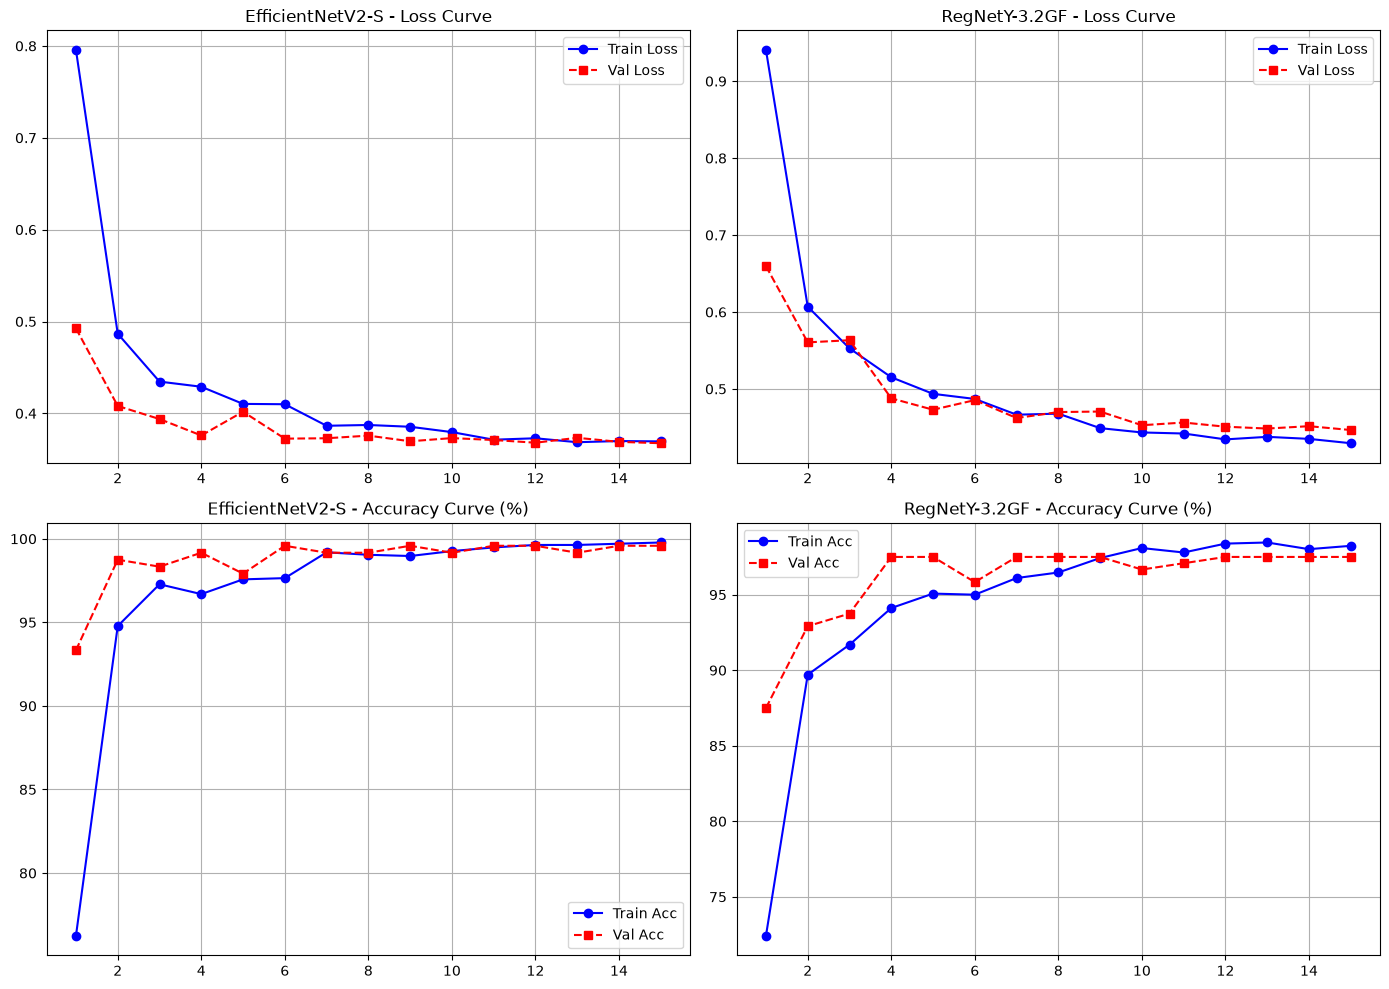

Đã lưu biểu đồ Loss/Accuracy vào training_curves.png


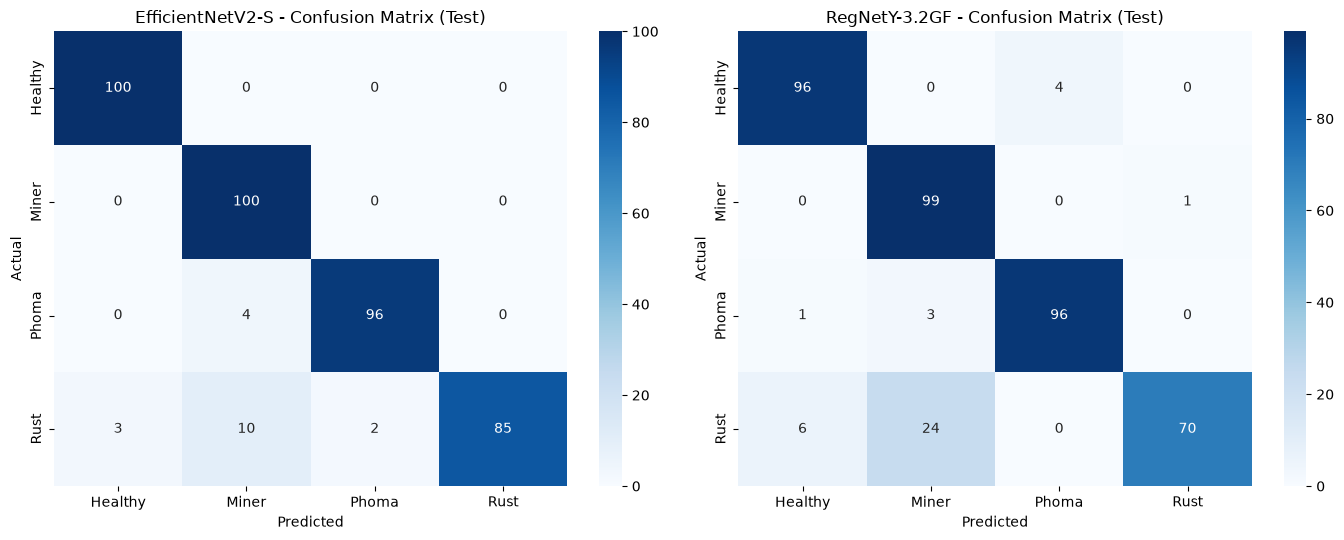

Đã lưu Confusion Matrix vào confusion_matrices.png


In [13]:
def display_research_report(results_list):
    print("\n" + "=" * 65)
    print("      BẢNG SO SÁNH KẾT QUẢ THỰC NGHIỆM (DÙNG CHO BÀI BÁO)")
    print("=" * 65)

    summary_data = []
    for res in results_list:
        summary_data.append({
            'Model': res['model_name'],
            'Test Acc (%)': round(res['accuracy'] * 100, 2),
            'Precision (Macro)': round(res['precision'], 4),
            'Recall (Macro)': round(res['recall'], 4),
            'F1 (Macro)': round(res['f1_score'], 4),
            'Params (M)': round(res['total_params_m'], 2),
            'Trainable Params (M)': round(res['trainable_params_m'], 2),
            'Model Size (MB)': round(res['model_size_mb'], 2),
            'Latency (ms/img)': round(res['latency_ms'], 2),
            'FPS': round(res['fps'], 1),
            'Max VRAM (MB)': round(res['max_vram_mb'], 1),
            'Train Time (s)': round(res['train_time_sec'], 1),
            'Delta Loss': round(res['delta_loss'], 4),
        })

    df = pd.DataFrame(summary_data)
    print(df.to_string(index=False))

    n = len(results_list)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 10), squeeze=False)
    for idx, res in enumerate(results_list):
        hist = res['history']
        epochs = range(1, len(hist['train_loss']) + 1)
        name = res['model_name']

        axes[0, idx].plot(epochs, hist['train_loss'], 'b-o', label='Train Loss')
        axes[0, idx].plot(epochs, hist['val_loss'], 'r--s', label='Val Loss')
        axes[0, idx].set_title(f'{name} - Loss Curve')
        axes[0, idx].legend(); axes[0, idx].grid(True)

        axes[1, idx].plot(epochs, [a * 100 for a in hist['train_acc']], 'b-o', label='Train Acc')
        axes[1, idx].plot(epochs, [a * 100 for a in hist['val_acc']], 'r--s', label='Val Acc')
        axes[1, idx].set_title(f'{name} - Accuracy Curve (%)')
        axes[1, idx].legend(); axes[1, idx].grid(True)

    plt.tight_layout()
    fig.savefig("training_curves.png", dpi=200, bbox_inches='tight')
    plt.show()
    print("Đã lưu biểu đồ Loss/Accuracy vào training_curves.png")

    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5.5), squeeze=False)
    for idx, res in enumerate(results_list):
        sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                    xticklabels=res['class_names'], yticklabels=res['class_names'], ax=axes[0, idx])
        axes[0, idx].set_title(f"{res['model_name']} - Confusion Matrix (Test)")
        axes[0, idx].set_xlabel('Predicted'); axes[0, idx].set_ylabel('Actual')

    plt.tight_layout()
    fig.savefig("confusion_matrices.png", dpi=200, bbox_inches='tight')
    plt.show()
    print("Đã lưu Confusion Matrix vào confusion_matrices.png")

    return df


summary_df = display_research_report([effnet_res, regnet_res])

## 10. Xuất kết quả ra file

Cell dưới lưu bảng số liệu tổng hợp và classification report ra file. Biểu đồ Loss/Accuracy (`training_curves.png`) và Confusion Matrix (`confusion_matrices.png`) đã được lưu tự động ở bước 9.

In [14]:
summary_df.to_csv("model_comparison_summary.csv", index=False)
print("Đã lưu bảng so sánh vào model_comparison_summary.csv")

for res in [effnet_res, regnet_res]:
    fname = f"classification_report_{res['model_name'].lower().replace('-', '_')}.txt"
    with open(fname, "w", encoding="utf-8") as f:
        f.write(res['classification_report'])
    print(f"Đã lưu {fname}")

Đã lưu bảng so sánh vào model_comparison_summary.csv
Đã lưu classification_report_efficientnetv2_s.txt
Đã lưu classification_report_regnety_3.2gf.txt
